# Linear Regression using Least Squares

## Linear Regression  
In statistics, linear regression is a linear approach to modelling the relationship between a dependent variable and one or more independent variables. In the case of one independent variable it is called simple linear regression. For more than one independent variable, the process is called mulitple linear regression.

Let **X** be the independent variable and **Y** be the dependent variable. We will define a linear relationship between these two variables as follows:  

\\[ Y = mX + c \\]  


This is the equation for a line that you studied in high school. **m** is the slope of the line and **c** is the y intercept. Today we will use this equation to train our model with a given dataset and predict the value of **Y** for any given value of **X**.  
  
Our challenege today is to determine the value of **m** and **c**, that gives the minimum error for the given dataset. We will be doing this by using the **Least Squares** method.  

## Finding the Error  
So to minimize the error we need a way to calculate the error in the first place. A **loss function** in machine learning is simply a measure of how different the predicted value is from the actual value.  
Today we will be using the **Quadratic Loss Function** to calculate the loss or error in our model. It can be defined as:
  
\\[ L(x) = \sum_{i=1}^n (y_i - p_i)^2\\]
  
We are squaring it because, for the points below the regression line **y - p** will be negative and we don't want negative values in our total error.  

## Least Squares method  
Now that we have determined the loss function, the only thing left to do is minimize it. This is done by finding the partial derivative of **L**, equating it to 0 and then finding an expression for **m** and **c**. After we do the math, we are left with these equations:    
  
\\[m = \frac{\sum_{i=1}^n (x_i - \bar x)(y_i - \bar y)}{\sum_{i=1}^n (x_i - \bar x)^2}\\]  
  
\\[c = \bar y - m\bar x\\]  
  
Here $\bar x$ is the mean of all the values in the input **X** and $\bar y$ is the mean of all the values in the desired output **Y**. This is the Least Squares method.
Now we will implement this in python and make predictions.  


## Implementing the Simple Linear Regression Model from Scratch

In [ ]:
# Making imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12.0, 9.0)

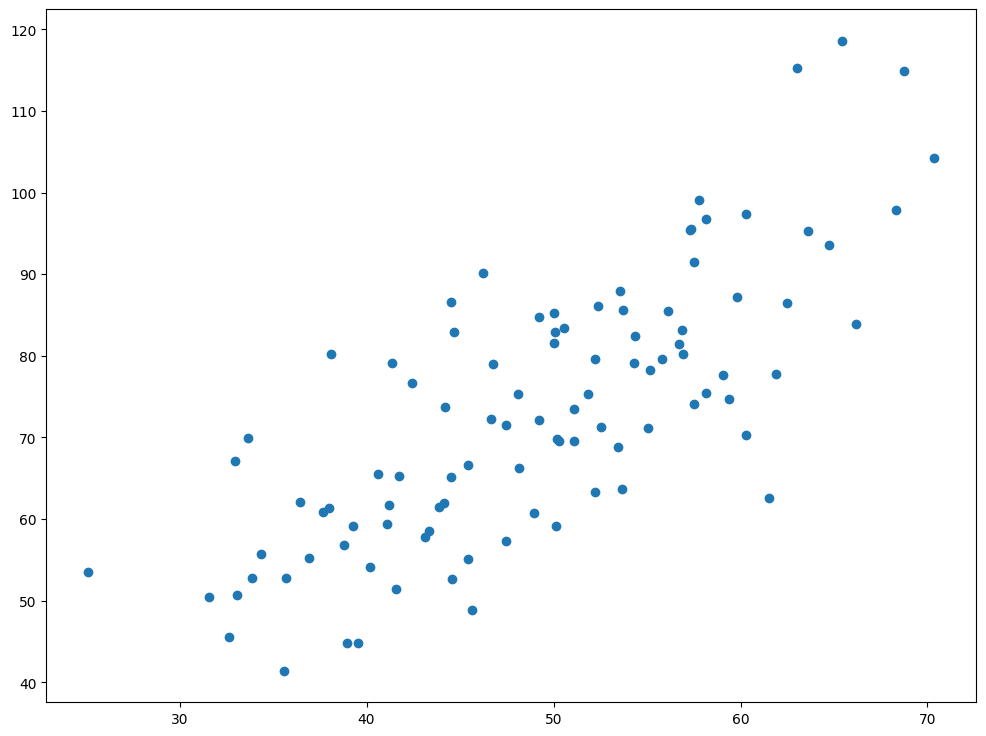

In [ ]:
# Preprocessing Input data
data = pd.read_csv('/content/data.csv')
X = data.iloc[:, 0]
Y = data.iloc[:, 1]
plt.scatter(X, Y)
plt.show()

In [ ]:
# Building the model
X_mean = np.mean(X)
Y_mean = np.mean(Y)

num = 0
den = 0
for i in range(len(X)):
    num += (X[i] - X_mean)*(Y[i] - Y_mean)
    den += (X[i] - X_mean)**2
m = num / den
c = Y_mean - m*X_mean

print (m, c)

1.2873573700109315 9.90860619032653


In [ ]:
print(f"The linear regression model is Y = {round(m, 4)}X + {round(c, 4)}") # f statement for in-line printing

The linear regression model is, 1.2874X + 9.9086


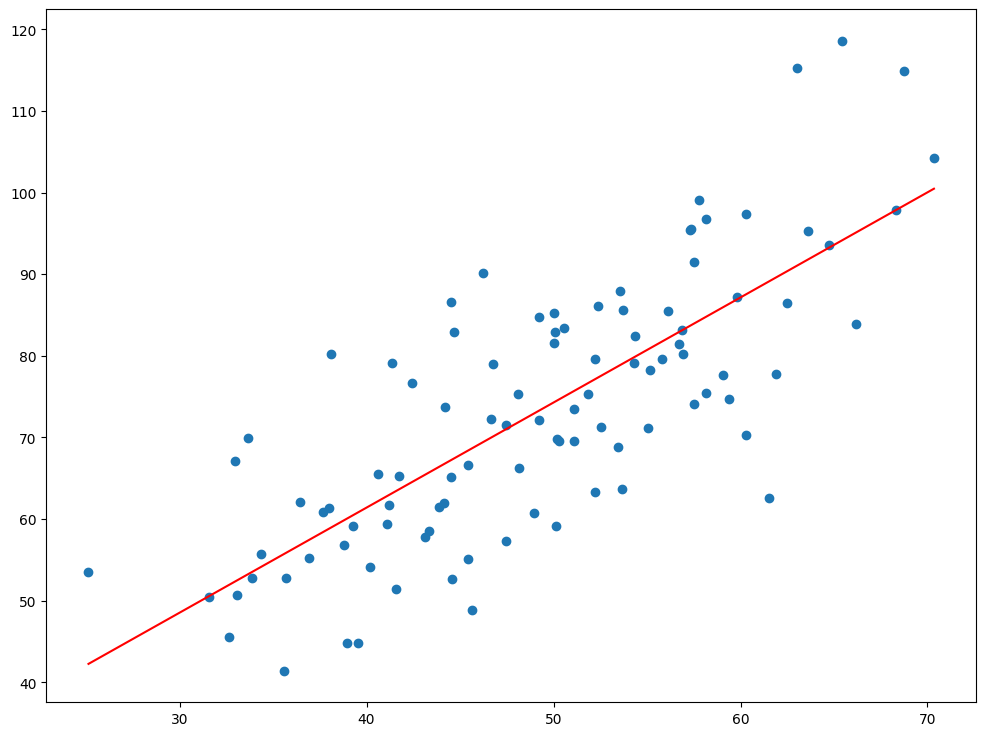

In [ ]:
# Making predictions
Y_pred = m*X + c

plt.scatter(X, Y) # actual
plt.plot([min(X), max(X)], [min(Y_pred), max(Y_pred)], color='red') # predicted
plt.show()

## Linear Regression with ols method

In [ ]:
import statsmodels.api as sm

In [ ]:
#add constant to predictor variables
X = sm.add_constant(X)

#fit linear regression model
model = sm.OLS(Y, X).fit()

#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      31.70700584656992   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     138.0
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           2.43e-20
Time:                        13:04:42   Log-Likelihood:                -372.00
No. Observations:                  99   AIC:                             748.0
Df Residuals:                      97   BIC:                             753.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  9.9086      5

# Linear Regression using Sklearn

## Linear Regression   
In statistics, linear regression is a linear approach to modelling the relationship between a dependent variable and one or more independent variables.
Let **X** be the independent variable and **Y** be the dependent variable. We will define a linear relationship between these two variables as follows:  

\\[ Y = mX + c \\]  

This is the equation for a line that you studied in high school. **m** is the slope of the line and **c** is the y intercept. Today we will use this equation to train our model with a given dataset and predict the value of **Y** for any given value of **X**.  
  
Our challenege today is to determine the value of **m** and **c**, such that the line corresponding to those values is the best fitting line or gives the minimum error.  

In [1]:
# Making the imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12.0, 9.0)

# Preprocessing Input data
data = pd.read_csv('/content/data.csv', header=None)

In [4]:
data.columns

Index([0, 1], dtype='int64')

In [5]:
data.columns = ['X', 'Y']
data.columns

Index(['X', 'Y'], dtype='object')

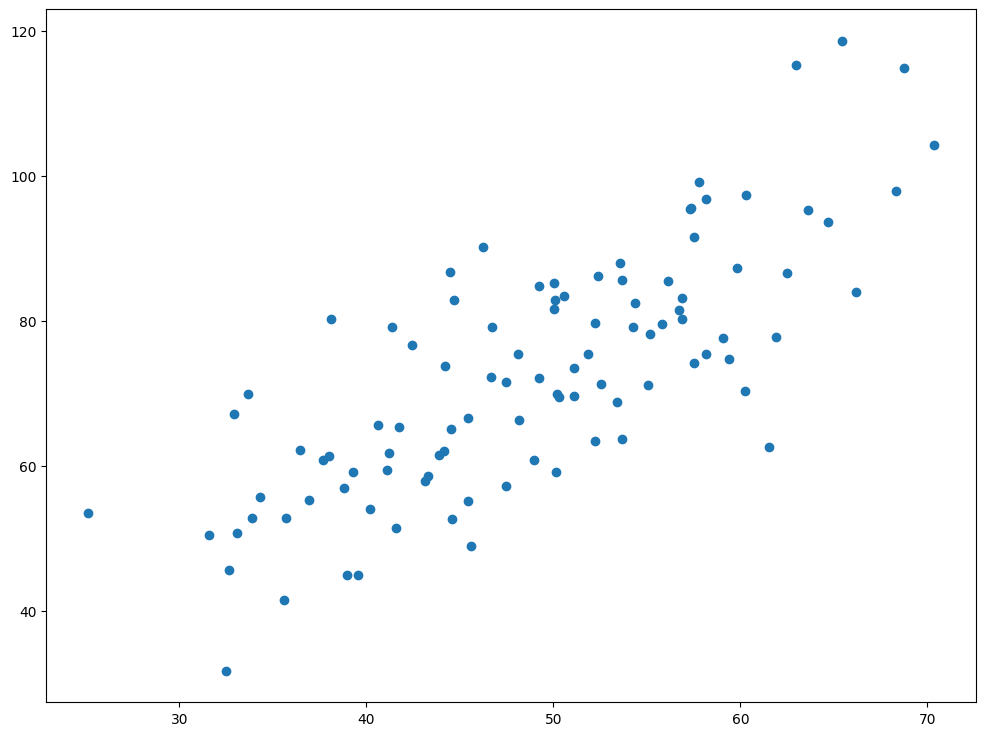

In [6]:
x = data['X']
y = data['Y']
plt.scatter(x, y)
plt.show()

In [ ]:
data.corr()

,X,Y
X,1.000000,0.773728
Y,0.773728,1.000000


In [ ]:
data.cov()

,X,Y
X,94.991910,125.620248
Y,125.620248,277.495208


In [ ]:
# Estimating Parameters
n = len(x)
mean_x = sum(x) / n
mean_y = sum(y) / n

numerator = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n))
denominator = sum((x[i] - mean_x)**2 for i in range(n))

m = numerator / denominator
c = mean_y - m * mean_x

In [ ]:
m

np.float64(1.322431022755359)

In [ ]:
c

np.float64(7.9910209822704275)

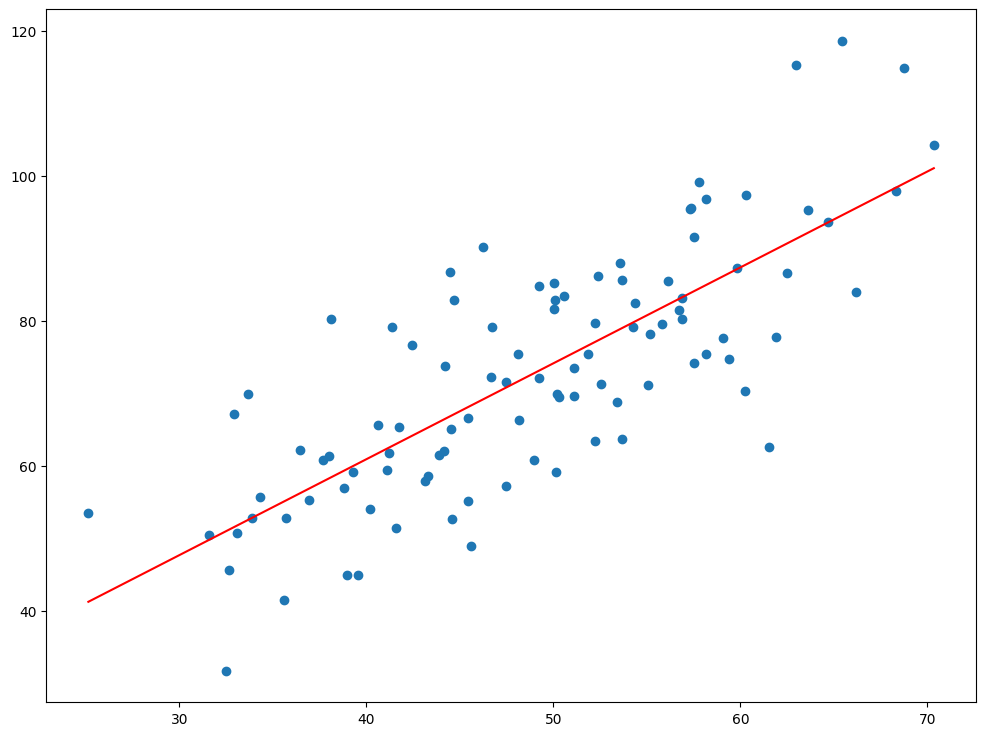

In [ ]:
# Making predictions
Y_pred = m*x + c

plt.scatter(x, y)
plt.plot([min(x), max(x)], [min(Y_pred), max(Y_pred)], color='red') # predicted
plt.show()

In [ ]:
# Compute R2
sst = sum((y[i] - mean_y)**2 for i in range(n)) # SST
sse = sum((y[i] - Y_pred[i])**2 for i in range(n)) # SSE
r2 = 1 - (sse / sst)
print("R-squared:", r2)

R-squared: 0.5986557915386619


## Linear Regrrsssion using scikit learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

In [7]:
X = data['X'].values.reshape(-1, 1) # values converts it into a numpy array
Y = data['Y'].values.reshape(-1, 1) # -1 means that calculate the dimension of rows, but have 1 column
linear_regressor = LinearRegression()
linear_regressor.fit(X, Y)
Y_pred = linear_regressor.predict(X)

In [8]:
print("Slope:", linear_regressor.coef_)
print("Intercept:", linear_regressor.intercept_)

Slope: [[1.32243102]]
Intercept: [7.99102098]


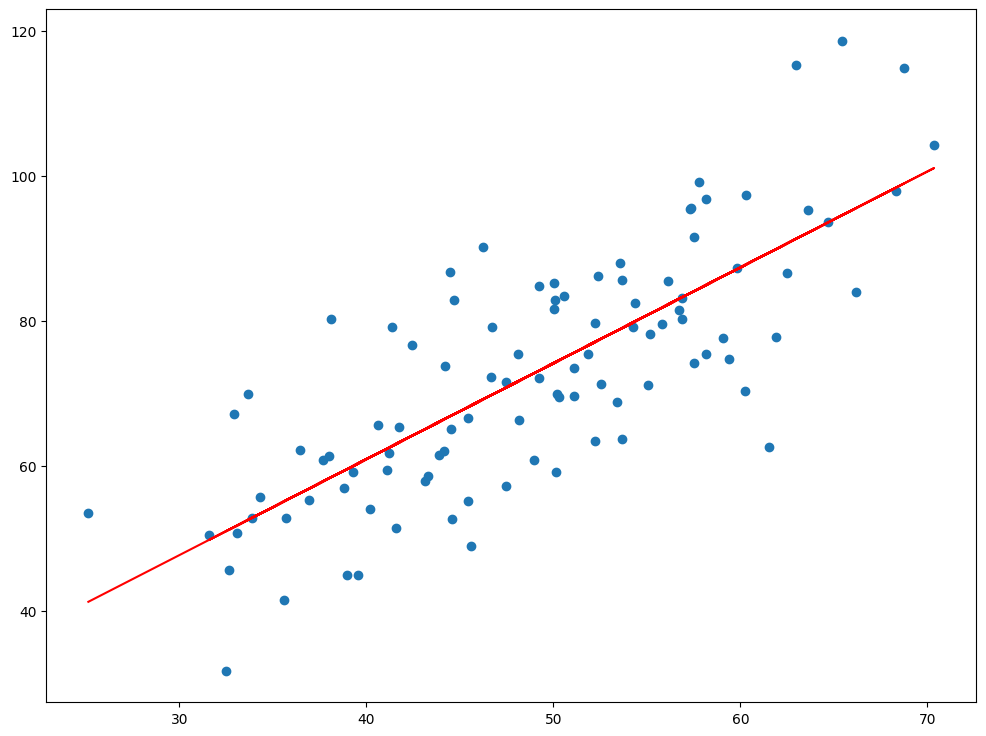

In [9]:
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.show()

In [10]:
from sklearn.metrics import r2_score
r2 = r2_score(Y, Y_pred)
print("R-squared (using sklearn):", r2)

R-squared (using sklearn): 0.5986557915386619


# Multiple Linear Regression

## Implementation from Scratch

In [11]:
import pandas as pd
import numpy as np

For the purposes we are going to use Housing dataset, where we need to learn the parameters for the training dataset and then make a prediction on the test dataset

Here, we are just using the features as-is and not doing any feature engineering

In [13]:
df_train = pd.read_csv('/content/kc_house_test_data.csv')
df_test = pd.read_csv('/content/kc_house_test_data.csv')

In [14]:
df_train

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,114101516,20140528T000000,310000.0,3,1.00,1430,19901,1.5,0,0,...,7,1430,0,1927,0,98028,47.7558,-122.229,1780,12697
1,9297300055,20150124T000000,650000.0,4,3.00,2950,5000,2.0,0,3,...,9,1980,970,1979,0,98126,47.5714,-122.375,2140,4000
2,1202000200,20141103T000000,233000.0,3,2.00,1710,4697,1.5,0,0,...,6,1710,0,1941,0,98002,47.3048,-122.218,1030,4705
3,8562750320,20141110T000000,580500.0,3,2.50,2320,3980,2.0,0,0,...,8,2320,0,2003,0,98027,47.5391,-122.070,2580,3980
4,7589200193,20141110T000000,535000.0,3,1.00,1090,3000,1.5,0,0,...,8,1090,0,1929,0,98117,47.6889,-122.375,1570,5080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4224,8672200110,20150317T000000,1088000.0,5,3.75,4170,8142,2.0,0,2,...,10,4170,0,2006,0,98056,47.5354,-122.181,3030,7980
4225,5087900040,20141017T000000,350000.0,4,2.75,2500,5995,2.0,0,0,...,8,2500,0,2008,0,98042,47.3749,-122.107,2530,5988
4226,3448900210,20141014T000000,610685.0,4,2.50,2520,6023,2.0,0,0,...,9,2520,0,2014,0,98056,47.5137,-122.167,2520,6023
4227,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200


In [ ]:
# dtype_dict = {'bathrooms':float, 'waterfront':int, 'sqft_above':int, 'sqft_living15':float, 'grade':int, 'yr_renovated':int, 'price':float, 'bedrooms':float, 'zipcode':str, 'long':float, 'sqft_lot15':float, 'sqft_living':float, 'floors':float, 'condition':int, 'lat':float, 'date':str, 'sqft_basement':int, 'yr_built':int, 'id':str, 'sqft_lot':int, 'view':int}
# df_train = pd.read_csv('/content/kc_house_train_data.csv', dtype=dtype_dict)
# df_test = pd.read_csv('/content/kc_house_test_data.csv', dtype=dtype_dict)

In [ ]:
df_train.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [ ]:
df_train.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.738400e+04,1.738400e+04,17384.000000,17384.000000,17384.000000,1.738400e+04,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000,17384.000000
mean,4.574349e+09,5.393666e+05,3.369363,2.115048,2080.029510,1.509191e+04,1.494248,0.007651,0.236079,3.410780,7.655028,1787.844512,292.184998,1971.152727,83.107973,98077.936896,47.559313,-122.213281,1985.994995,12776.380867
std,2.872356e+09,3.696912e+05,0.906468,0.771783,921.630888,4.145927e+04,0.539443,0.087136,0.768008,0.649792,1.169818,827.107595,444.404136,29.328722,398.692283,53.525617,0.138703,0.140906,686.512835,27175.730523
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.159300,-122.519000,399.000000,651.000000
25%,2.124087e+09,3.200000e+05,3.000000,1.750000,1420.000000,5.049500e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1952.000000,0.000000,98033.000000,47.468650,-122.328000,1490.000000,5100.000000
50%,3.892800e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.616000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571400,-122.229000,1840.000000,7620.000000
75%,7.304301e+09,6.400000e+05,4.000000,2.500000,2550.000000,1.066525e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98117.000000,47.677625,-122.125000,2360.000000,10065.250000
max,9.900000e+09,7.700000e+06,10.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df_train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df_test.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,114101516,20140528T000000,310000.0,3,1.0,1430,19901,1.5,0,0,...,7,1430,0,1927,0,98028,47.7558,-122.229,1780,12697
1,9297300055,20150124T000000,650000.0,4,3.0,2950,5000,2.0,0,3,...,9,1980,970,1979,0,98126,47.5714,-122.375,2140,4000
2,1202000200,20141103T000000,233000.0,3,2.0,1710,4697,1.5,0,0,...,6,1710,0,1941,0,98002,47.3048,-122.218,1030,4705
3,8562750320,20141110T000000,580500.0,3,2.5,2320,3980,2.0,0,0,...,8,2320,0,2003,0,98027,47.5391,-122.070,2580,3980
4,7589200193,20141110T000000,535000.0,3,1.0,1090,3000,1.5,0,0,...,8,1090,0,1929,0,98117,47.6889,-122.375,1570,5080


In [15]:
# Select necessary columns from training and test datasets

df_train = df_train[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','sqft_living15','sqft_lot15']]
df_test = df_test[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','sqft_living15','sqft_lot15']]

In [16]:
# Separate the Target variable from the training dataset
Y = np.array(df_train['price'])

In [17]:
X = df_train.drop(['price'], axis=1)
H = np.array(X)

# Add a vector of 1s to the numpy array to represent the 1st feature
ones = np.ones(len(H))
H = np.column_stack((ones,H))

In [18]:
# Calculate the parameter weights using the Closed Form solution of multiple linear regression
w = np.dot(np.linalg.pinv(np.dot(np.transpose(H),H)),np.dot(np.transpose(H),Y))

In [ ]:
w # W are the regression coefficient matrix

array([-6.91987375e+05, -3.93524052e+04, -1.52851588e+04,  1.37689680e+02,
        7.99601476e-02, -6.02198592e+03,  6.09498294e+05,  5.62440119e+04,
        5.36268725e+04,  1.03070360e+05,  5.27614787e+01,  8.53259146e+01,
        9.50017959e+00, -8.07448536e-01])

In [19]:
# Now we have the parameter weights and this can be used to make predictions on unseen data.
X_test = df_test.drop(['price'], axis=1)
H = np.array(X_test)
ones = np.ones(len(H))
H = np.column_stack((ones,H))
prediction = np.dot(H,w)

In [20]:
prediction

array([395132.75888688, 997092.63281377, 388162.48789937, ...,
       694816.8960286 , 554491.52148586, 292799.30074337])

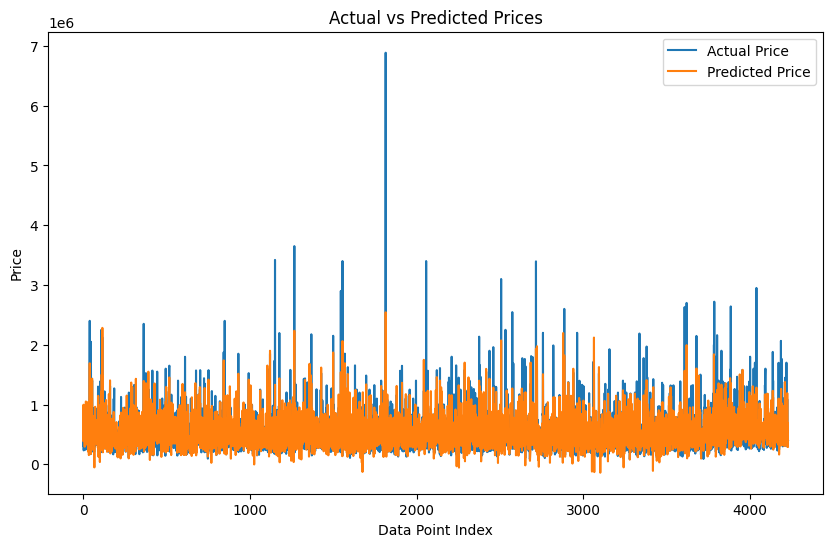

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(df_test['price'], label='Actual Price')
plt.plot(prediction, label='Predicted Price')
plt.xlabel("Data Point Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

In [22]:
((np.array(df_test['price']) - prediction)**2).mean() # Squared Error

np.float64(50836543859.39354)

## Using scikit learn

In [23]:
# Seperate the features from the training and testing dataset
X_train = np.array(df_train.drop(['price'], axis=1))
X_test = np.array(df_test.drop(['price'], axis=1))

In [24]:
# Separate the Target variable from the training and testing dataset
Y_train = np.array(df_train['price'])
Y_test = np.array(df_test['price'])

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
y_pred = lr.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error as mse
mse(Y_test, y_pred)

50836543859.39348

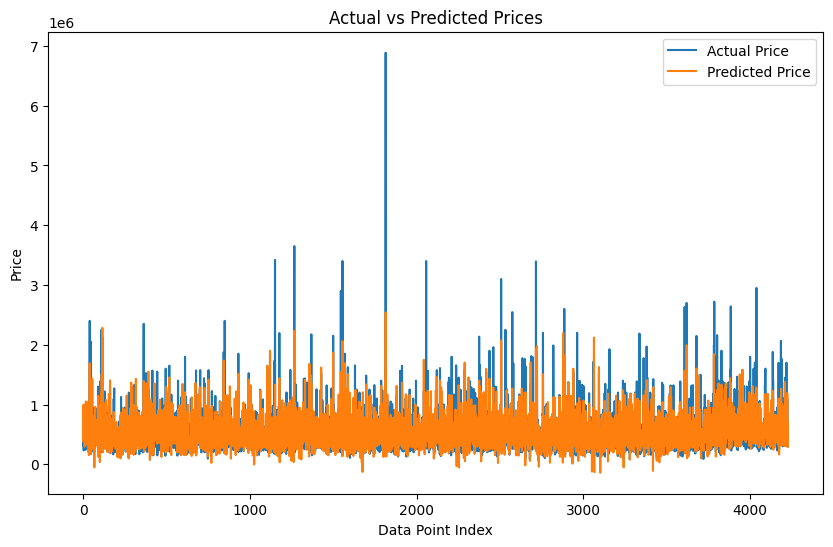

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(Y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.xlabel("Data Point Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

In [29]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, y_pred)
print("R-squared (using sklearn):", r2)

R-squared (using sklearn): 0.5997313688418179
